In [ ]:
# Data collection command:
# `python comet_download.py --project=stationary-optimizer-comparison --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
save_path = 'figures/'
config_data_path = 'data/stationary-optimizer-comparison_params.csv'
run_data_path = 'data/stationary-optimizer-comparison_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
del config_dfs[np.nan], run_dfs[np.nan]

# Fix for me actidentally using the same sweep name in Autostep and UPGD configs
mixed_config_df = config_dfs['autostep']
mixed_run_df = run_dfs['autostep']

upgd_config_rows = mixed_config_df[mixed_config_df['optimizer|name'] == 'upgd']
upgd_run_ids = upgd_config_rows['run_id'].unique()
upgd_run_rows = mixed_run_df[mixed_run_df['run_id'].isin(upgd_run_ids)]

autostep_config_rows = mixed_config_df[mixed_config_df['optimizer|name'] == 'idbd']
autostep_run_ids = autostep_config_rows['run_id'].unique()
autostep_run_rows = mixed_run_df[mixed_run_df['run_id'].isin(autostep_run_ids)]

config_dfs['autostep'] = autostep_config_rows
run_dfs['autostep'] = autostep_run_rows

config_dfs['upgd'] = upgd_config_rows
run_dfs['upgd'] = upgd_run_rows
config_dfs['upgd']['sweep_name'] = 'upgd'

{k: len(v) for k, v in config_dfs.items()}

/tmp/ipykernel_11047/1145499777.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  config_dfs['upgd']['sweep_name'] = 'upgd'


{'autostep_feature_search': 1800,
 'autostep': 5,
 'feature_search_only': 1125,
 'autostep_ideal_features': 5,
 'input_range_impact': 10,
 'upgd': 2160}

In [4]:
print("_____Best Hyperparameter Configurations_____")

sweep_split_vars = {
    'upgd': ['model|activation'],
}

best_config_dfs, best_run_dfs, best_hyperparam_vals = get_best_ablation_values(
    config_dfs, run_dfs, sweep_split_vars=sweep_split_vars, split_dfs_by_split_vars=True)

_____Best Hyperparameter Configurations_____

=== autostep_feature_search ===

Configuration: (no split vars) | # runs: 5
  Best feature_recycling|recycle_rate=0.0
  Best optimizer|meta_learning_rate=2**-10
  Best optimizer|learning_rate=2**4
  Best feature_recycling|utility_decay=0.99


=== autostep ===

Configuration: (no split vars) | # runs: 5


=== feature_search_only ===

Configuration: (no split vars) | # runs: 5
  Best feature_recycling|recycle_rate=0.0
  Best optimizer|meta_learning_rate=2**-10
  Best optimizer|learning_rate=2**-8
  Best feature_recycling|utility_decay=0.99


=== autostep_ideal_features ===

Configuration: (no split vars) | # runs: 5


=== input_range_impact ===

Configuration: (no split vars) | # runs: 5
  Best model|n_frozen_layers=2**0
  Best model|use_perfect_features=True


=== upgd ===

Configuration: model|activation=ltu | # runs: 5
  Best optimizer|learning_rate=2**-12
  Best optimizer|beta_utility=0.999
  Best optimizer|sigma=0.0001
  Best optimizer|w

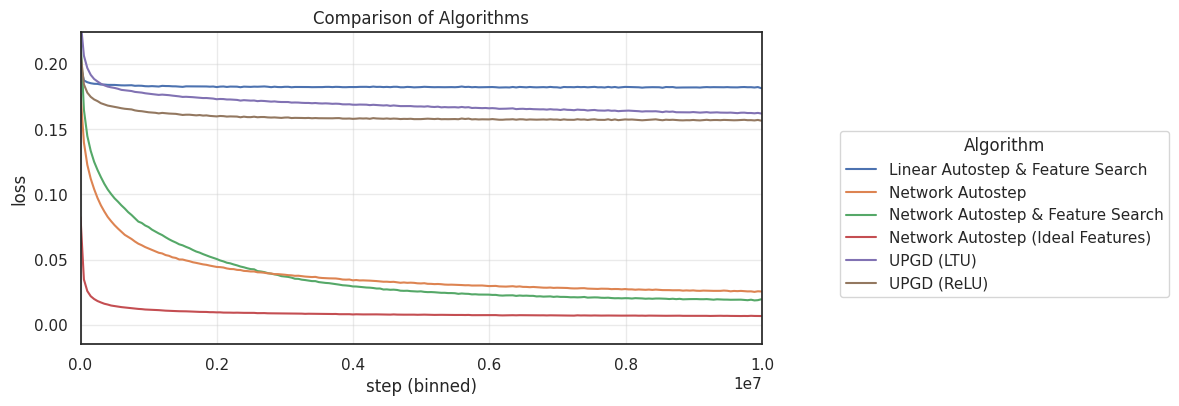

In [5]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(
    [df.assign(split_name=k) for k, df in best_config_dfs.items()]
)

algo_map = {
    'autostep': 'Network Autostep',
    'autostep_feature_search': 'Network Autostep & Feature Search',
    'feature_search_only': 'Linear Autostep & Feature Search',
    'autostep_ideal_features': 'Network Autostep (Ideal Features)',
    'upgd&model|activation=relu': 'UPGD (ReLU)',
    'upgd&model|activation=ltu': 'UPGD (LTU)',
}

# Only keep rows whose split_name is in algo_map
combined_config_df = combined_config_df[combined_config_df['split_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['split_name'].map(algo_map)


plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.title('Comparison of Algorithms')
plt.show()

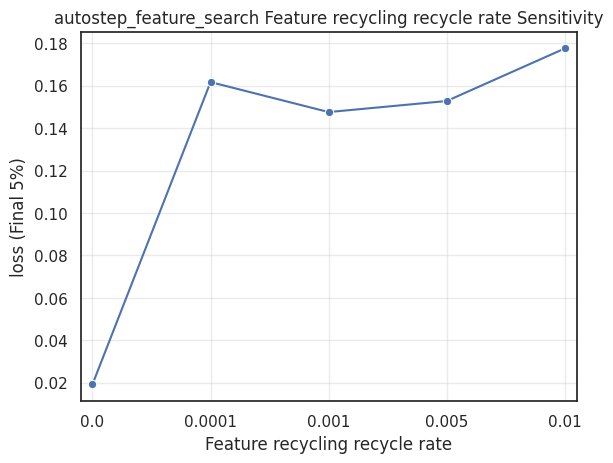

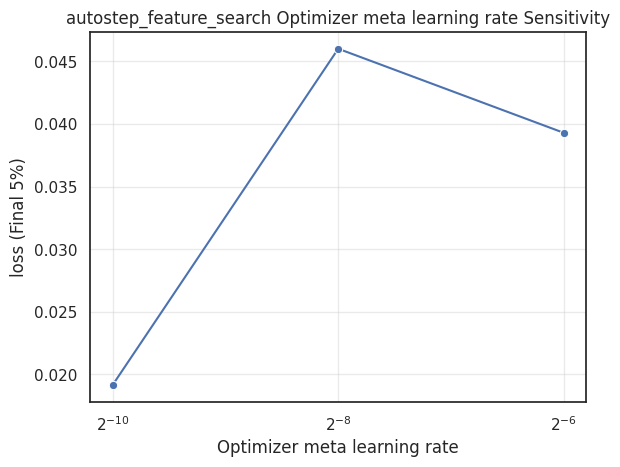

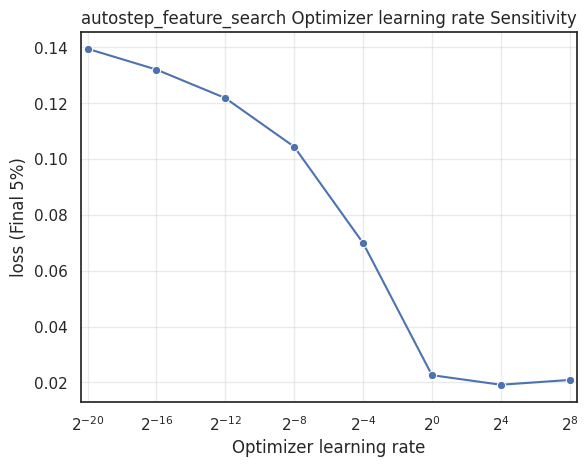

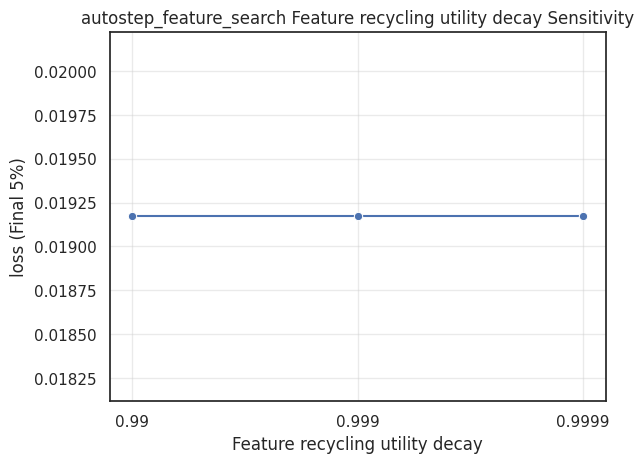

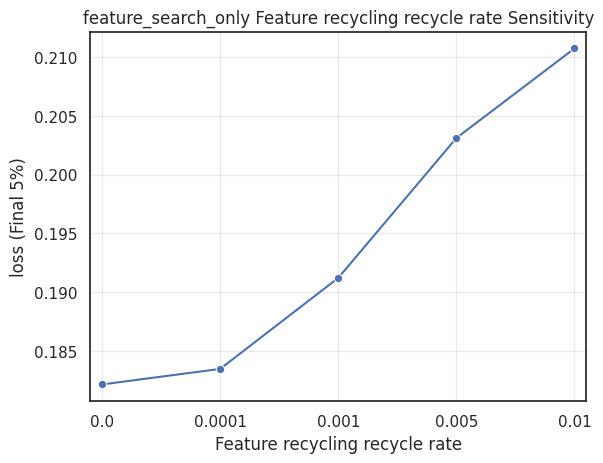

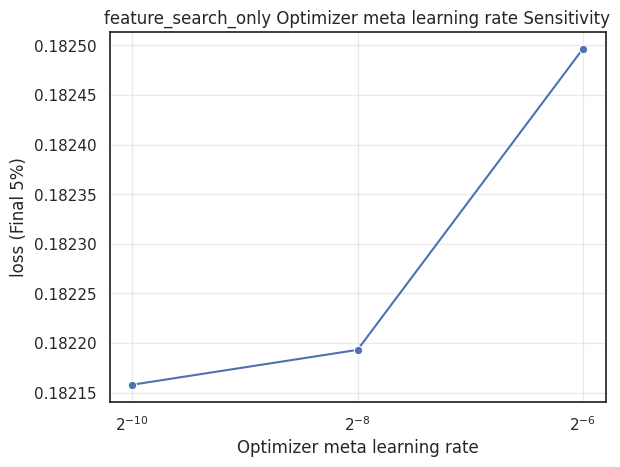

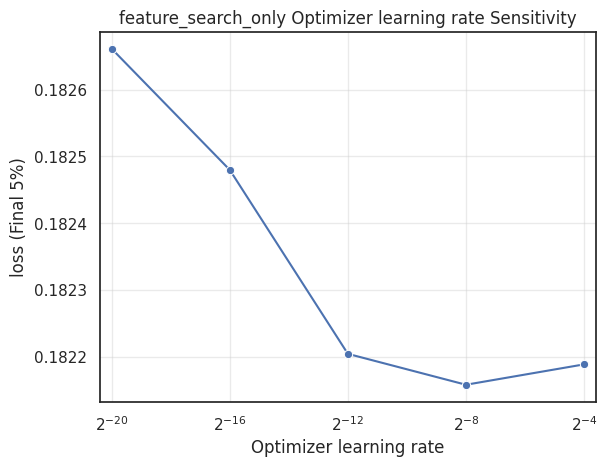

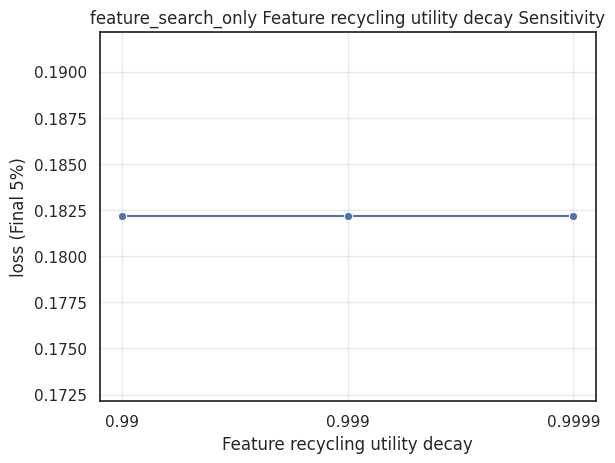

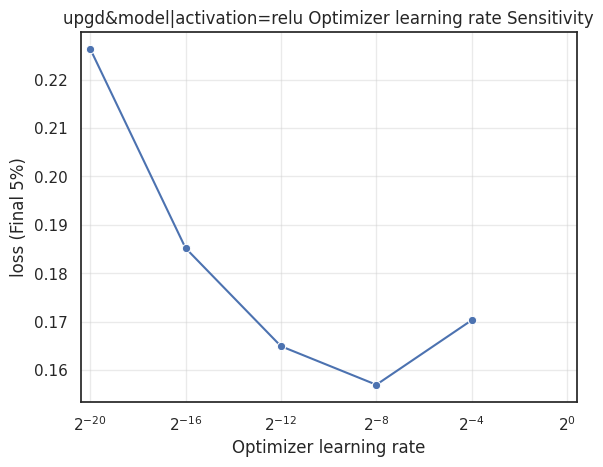

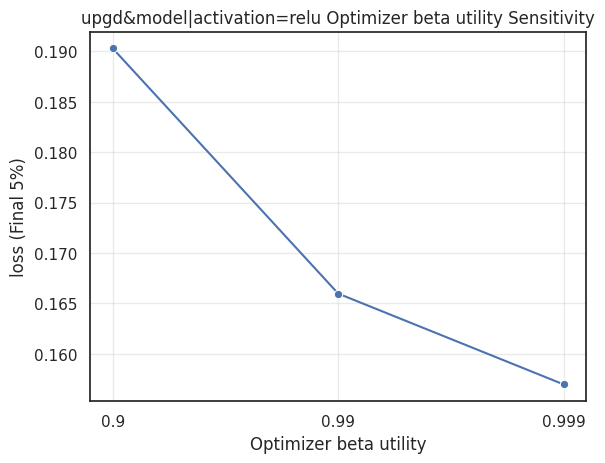

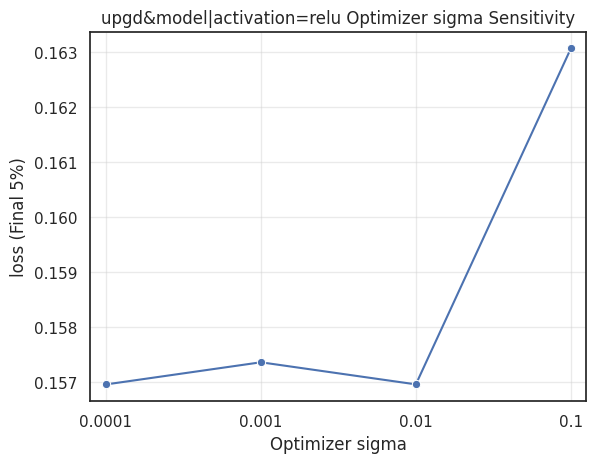

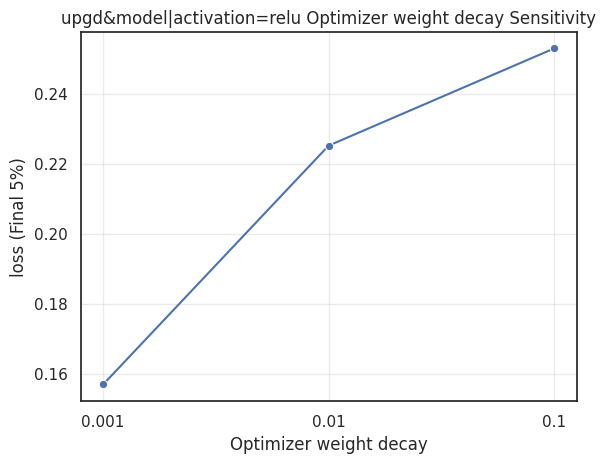

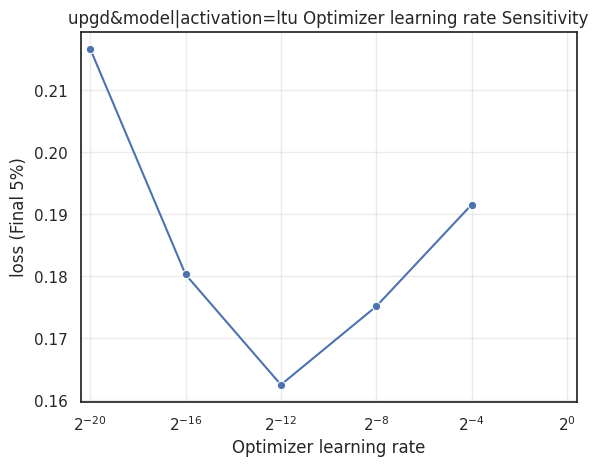

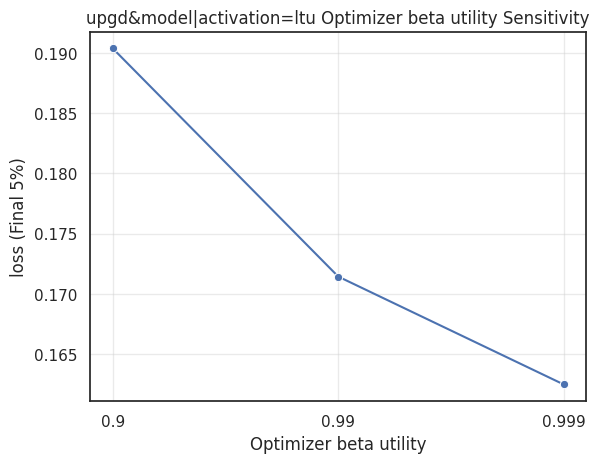

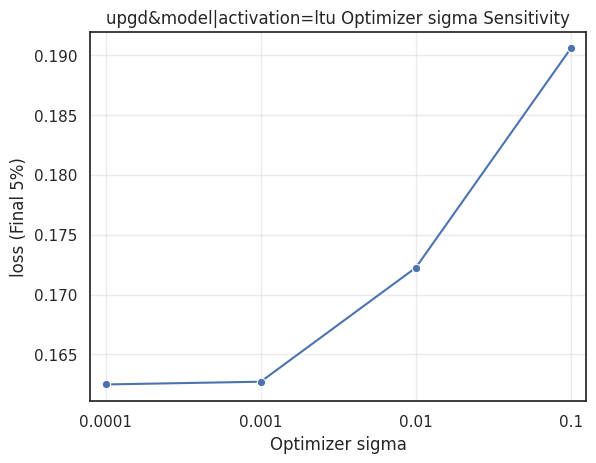

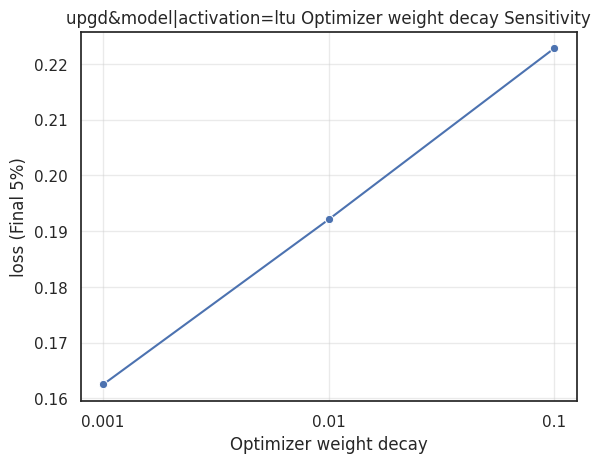

In [6]:
sensitivity_sweep_names = [
    'autostep', 'autostep_feature_search', 'feature_search_only', 'autostep_ideal_features',
    'upgd&model|activation=relu', 'upgd&model|activation=ltu',
]

config_dfs['upgd&model|activation=ltu'] = config_dfs['upgd'][config_dfs['upgd']['model|activation'] == 'ltu'].copy()
run_ids = config_dfs['upgd&model|activation=ltu']['run_id'].unique()
run_dfs['upgd&model|activation=ltu'] = run_dfs['upgd'][run_dfs['upgd']['run_id'].isin(run_ids)].copy()

config_dfs['upgd&model|activation=relu'] = config_dfs['upgd'][config_dfs['upgd']['model|activation'] == 'relu'].copy()
run_ids = config_dfs['upgd&model|activation=relu']['run_id'].unique()
run_dfs['upgd&model|activation=relu'] = run_dfs['upgd'][run_dfs['upgd']['run_id'].isin(run_ids)].copy()

for target_df in sensitivity_sweep_names:
    default_hyperparams = best_hyperparam_vals[target_df]

    plot_config_df = config_dfs[target_df]
    valid_run_ids = plot_config_df['run_id'].unique()
    plot_run_df = run_dfs[target_df][run_dfs[target_df]['run_id'].isin(valid_run_ids)].copy()

    for param_name, param_value in default_hyperparams.items():
        selected_run_df, selected_config_df = select_experiment_runs(
            run_df = plot_run_df,
            config_df = plot_config_df,
            chosen_values = {
                k: v for k, v in default_hyperparams.items()
                if k != param_name
            },
        )
        
        param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
        
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{target_df} {param_label} Sensitivity',
                x_label = param_label,
                y_label = 'loss',
                metric_col = 'loss',
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                legend_title = None,
                show_ci = False,
                baseline_col = None,
                pow_2_x_axis = 'learning_rate' in param_name,
                pow_2_legend = True,
            )
        plt.show()